# Dijkstra's Algorithm (Binary Heap) — Complexity & Scalability Study

This notebook runs **Dijkstra's single-source shortest-path algorithm**, implemented
with a **binary heap** (`heapq`), on five real-world social-network graphs and
compares them **by size (number of nodes)**.

For every dataset we measure:

| Metric | How it is measured |
|--------|--------------------|
| **Execution time** | `time.perf_counter()` around a full single-source run |
| **Memory** | `tracemalloc` peak allocation during the run |
| **Scalability** | repeated runs on growing sub-graphs (BFS-sampled) → time vs. size curve |
| **Running times** | distribution of times over many random source nodes |

The binary-heap Dijkstra has time complexity **O((V + E) · log V)** and space
complexity **O(V + E)**. We overlay this theoretical curve on the empirical results.

### Datasets
| File | Format | Weighted? |
|------|--------|-----------|
| `soc-advogato.edges`         | edge list `u v w` | yes (trust) |
| `soc-sign-bitcoinalpha.edges`| CSV `u,v,rating,t` | yes (signed rating) |
| `soc-sign-bitcoinotc.edges`  | CSV `u,v,rating,t` | yes (signed rating) |
| `soc-epinions.mtx`           | MatrixMarket pattern | unweighted |
| `soc-LiveMocha.mtx`          | MatrixMarket pattern | unweighted |


In [1]:
import os, time, heapq, tracemalloc, random
from collections import defaultdict, deque

import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
print("Imports ready.")

Imports ready.


## 1. Loading the graphs

Each format is parsed into a single representation: an **adjacency list**
`graph: dict[node] -> list[(neighbor, weight)]`.

Dijkstra requires **non-negative** weights. The Bitcoin datasets carry signed
trust ratings in `[-10, 10]`, so we map a rating `r` to a positive cost
`cost = 11 - r` (higher trust ⇒ lower cost), which keeps every weight in `[1, 21]`.
Unweighted `.mtx` graphs use unit weights.

In [2]:
def add_edge(graph, u, v, w):
    graph[u].append((v, w))
    graph[v].append((u, w))   # treat all graphs as undirected for connectivity

def load_edges_space(path):
    '''soc-advogato.edges : '% comment' lines, then 'u v w'.'''
    g = defaultdict(list)
    with open(path) as f:
        for line in f:
            if not line.strip() or line.startswith('%'):
                continue
            p = line.split()
            u, v = int(p[0]), int(p[1])
            w = float(p[2]) if len(p) > 2 else 1.0
            w = abs(w) if w != 0 else 1.0
            add_edge(g, u, v, w)
    return g

def load_edges_csv_rating(path):
    '''bitcoin*.edges : 'u,v,rating,time' -> cost = 11 - rating (in [1,21]).'''
    g = defaultdict(list)
    with open(path) as f:
        for line in f:
            if not line.strip() or line.startswith('%'):
                continue
            p = line.split(',')
            u, v = int(p[0]), int(p[1])
            rating = float(p[2])
            cost = 11.0 - rating          # rating in [-10,10] -> cost in [1,21]
            add_edge(g, u, v, cost)
    return g

def load_mtx_pattern(path):
    '''MatrixMarket 'pattern' graph: skip %-header + dims line, then 'u v'.'''
    g = defaultdict(list)
    with open(path) as f:
        seen_dims = False
        for line in f:
            if not line.strip() or line.startswith('%'):
                continue
            if not seen_dims:        # first non-comment line is 'rows cols nnz'
                seen_dims = True
                continue
            p = line.split()
            u, v = int(p[0]), int(p[1])
            add_edge(g, u, v, 1.0)   # unweighted -> unit cost
    return g

DATASETS = [
    ("advogato",     "soc-advogato.edges",          load_edges_space),
    ("bitcoin-alpha","soc-sign-bitcoinalpha.edges", load_edges_csv_rating),
    ("bitcoin-otc",  "soc-sign-bitcoinotc.edges",   load_edges_csv_rating),
    ("epinions",     "soc-epinions.mtx",            load_mtx_pattern),
    ("livemocha",    "soc-LiveMocha.mtx",           load_mtx_pattern),
]
print("Loaders defined for", len(DATASETS), "datasets.")

Loaders defined for 5 datasets.


In [3]:
graphs = {}
for name, path, loader in DATASETS:
    if not os.path.exists(path):
        print(f"!! missing {path}, skipping"); continue
    g = loader(path)
    V = len(g)
    E = sum(len(adj) for adj in g.values()) // 2
    graphs[name] = g
    print(f"{name:14s}  V = {V:>7,}  E = {E:>9,}")


advogato        V =   6,551  E =    51,332
bitcoin-alpha   V =   3,783  E =    24,186
bitcoin-otc     V =   5,881  E =    35,592


epinions        V =  26,588  E =   100,120


livemocha       V = 104,103  E = 2,193,083


## 2. Dijkstra with a binary heap

Standard lazy-deletion implementation using Python's `heapq` (a binary min-heap).
Each edge can push one entry onto the heap; stale entries are skipped on pop.

**Time:** `O((V + E) log V)` &nbsp;&nbsp; **Space:** `O(V + E)`

In [4]:
def dijkstra(graph, source):
    '''Single-source shortest paths from `source`. Returns dist dict.'''
    dist = {source: 0.0}
    visited = set()
    heap = [(0.0, source)]            # (distance, node) — binary heap
    while heap:
        d, u = heapq.heappop(heap)    # pop smallest: O(log V)
        if u in visited:
            continue                  # stale entry — skip
        visited.add(u)
        for v, w in graph[u]:
            nd = d + w
            if nd < dist.get(v, float('inf')):
                dist[v] = nd
                heapq.heappush(heap, (nd, v))   # push: O(log V)
    return dist

# sanity check on a tiny graph
_t = defaultdict(list)
for a, b, w in [(1,2,4),(1,3,1),(3,2,1),(2,4,1)]:
    _t[1]; add_edge(_t, a, b, w)
print("sanity dist from 1:", {k: _t and v for k, v in dijkstra(_t, 1).items()})

sanity dist from 1: {1: 0.0, 2: 2.0, 3: 1.0, 4: 3.0}


## 3. Measuring execution time and memory

For each dataset we run a full single-source Dijkstra from a fixed source,
timing it with `perf_counter` and capturing the **peak** memory with
`tracemalloc`. We also record `V`, `E`, and the theoretical work
`(V + E)·log2(V)` to compare against.

In [5]:
def first_node(graph):
    return next(iter(graph))

def measure_once(graph, source):
    tracemalloc.start()
    t0 = time.perf_counter()
    dist = dijkstra(graph, source)
    t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return t1 - t0, peak, len(dist)

results = []
for name in graphs:
    g = graphs[name]
    src = first_node(g)
    V = len(g)
    E = sum(len(a) for a in g.values()) // 2
    # average wall time over a few runs for stability
    times = []
    for _ in range(3):
        t, peak, reached = measure_once(g, src)
        times.append(t)
    results.append({
        "name": name, "V": V, "E": E,
        "time_s": float(np.mean(times)),
        "time_std": float(np.std(times)),
        "mem_mb": peak / 1e6,
        "reached": reached,
        "VE_logV": (V + E) * np.log2(max(V, 2)),
    })

results.sort(key=lambda r: r["V"])          # order by size (#nodes)
print(f"{'dataset':14s}{'V':>9}{'E':>11}{'time(s)':>10}{'mem(MB)':>10}{'reached':>9}")
for r in results:
    print(f"{r['name']:14s}{r['V']:>9,}{r['E']:>11,}{r['time_s']:>10.4f}{r['mem_mb']:>10.1f}{r['reached']:>9,}")


dataset               V          E   time(s)   mem(MB)  reached
bitcoin-alpha     3,783     24,186    0.0207       0.5    3,775
bitcoin-otc       5,881     35,592    0.0378       1.2    5,875
advogato          6,551     51,332    0.0459       1.0    5,054
epinions         26,588    100,120    0.1163       4.9   26,588
livemocha       104,103  2,193,083    2.1846      16.0  104,103


## 4. Comparing datasets by size (number of nodes)

The four panels below compare all datasets, ordered by node count.

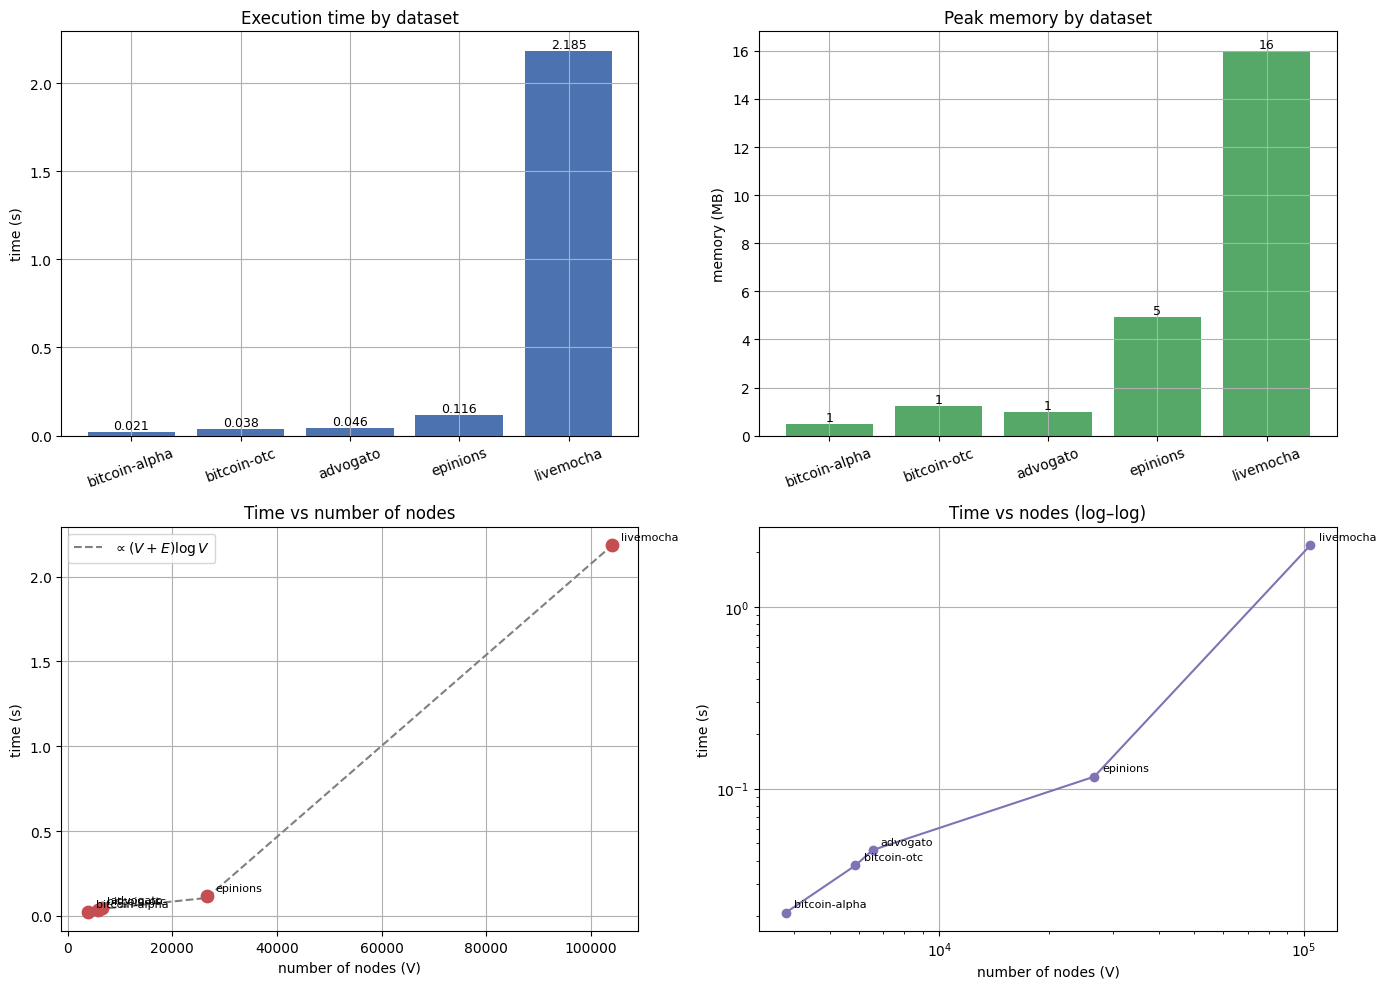

In [6]:
names   = [r["name"] for r in results]
Vs      = np.array([r["V"]       for r in results], float)
Es      = np.array([r["E"]       for r in results], float)
times   = np.array([r["time_s"]  for r in results], float)
mems    = np.array([r["mem_mb"]  for r in results], float)
work    = np.array([r["VE_logV"] for r in results], float)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) execution time vs #nodes
ax = axes[0, 0]
ax.bar(names, times, color="#4C72B0")
ax.set_title("Execution time by dataset")
ax.set_ylabel("time (s)"); ax.tick_params(axis='x', rotation=20)
for i, t in enumerate(times):
    ax.text(i, t, f"{t:.3f}", ha="center", va="bottom", fontsize=9)

# (b) peak memory vs #nodes
ax = axes[0, 1]
ax.bar(names, mems, color="#55A868")
ax.set_title("Peak memory by dataset")
ax.set_ylabel("memory (MB)"); ax.tick_params(axis='x', rotation=20)
for i, m in enumerate(mems):
    ax.text(i, m, f"{m:.0f}", ha="center", va="bottom", fontsize=9)

# (c) time vs nodes with theoretical (V+E)logV trend
ax = axes[1, 0]
ax.scatter(Vs, times, s=80, color="#C44E52", zorder=3)
for x, y, n in zip(Vs, times, names):
    ax.annotate(n, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)
scale = times[-1] / work[-1]                      # fit constant to largest point
order = np.argsort(Vs)
ax.plot(Vs[order], (work * scale)[order], "--", color="gray",
        label=r"$\propto (V+E)\log V$")
ax.set_title("Time vs number of nodes")
ax.set_xlabel("number of nodes (V)"); ax.set_ylabel("time (s)")
ax.legend()

# (d) log-log time vs nodes
ax = axes[1, 1]
ax.loglog(Vs, times, "o-", color="#8172B3")
for x, y, n in zip(Vs, times, names):
    ax.annotate(n, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_title("Time vs nodes (log–log)")
ax.set_xlabel("number of nodes (V)"); ax.set_ylabel("time (s)")

plt.tight_layout()
plt.show()

## 5. Scalability — growing sub-graphs

To see how each algorithm run **scales within a single graph**, we take the
largest dataset and run Dijkstra on **BFS-sampled connected sub-graphs** of
increasing size (≈10% … 100% of nodes). Plotting time against sub-graph size
and overlaying the `(V+E)·log V` curve shows the empirical growth rate.

In [7]:
def bfs_subgraph(graph, source, max_nodes):
    '''Connected sub-graph (induced) reachable from source, capped at max_nodes.'''
    keep, q = {source}, deque([source])
    while q and len(keep) < max_nodes:
        u = q.popleft()
        for v, _ in graph[u]:
            if v not in keep:
                keep.add(v)
                if len(keep) < max_nodes:
                    q.append(v)
    sub = defaultdict(list)
    for u in keep:
        sub[u] = [(v, w) for v, w in graph[u] if v in keep]
    return sub

scale_name = results[-1]["name"]            # largest by #nodes
G = graphs[scale_name]
src = first_node(G)
full_V = len(G)
fractions = [0.1, 0.2, 0.35, 0.5, 0.65, 0.8, 1.0]

scal = []
for frac in fractions:
    cap = max(2, int(full_V * frac))
    sub = bfs_subgraph(G, src, cap)
    V = len(sub)
    E = sum(len(a) for a in sub.values()) // 2
    ts = []
    for _ in range(3):
        t, _, _ = measure_once(sub, src)
        ts.append(t)
    scal.append({"V": V, "E": E, "time": float(np.mean(ts)),
                 "VE_logV": (V + E) * np.log2(max(V, 2))})
    print(f"frac={frac:>4}: V={V:>7,} E={E:>9,} time={np.mean(ts):.4f}s")

sv  = np.array([s["V"]       for s in scal], float)
st  = np.array([s["time"]    for s in scal], float)
sw  = np.array([s["VE_logV"] for s in scal], float)

frac= 0.1: V= 11,377 E=  203,522 time=0.1467s


frac= 0.2: V= 21,542 E=  440,594 time=0.3432s


frac=0.35: V= 36,720 E=  719,369 time=0.5944s


frac= 0.5: V= 52,069 E=1,069,757 time=0.9242s


frac=0.65: V= 68,040 E=1,340,632 time=1.2087s


frac= 0.8: V= 84,442 E=1,584,809 time=1.4857s


frac= 1.0: V=104,103 E=2,193,083 time=2.0423s


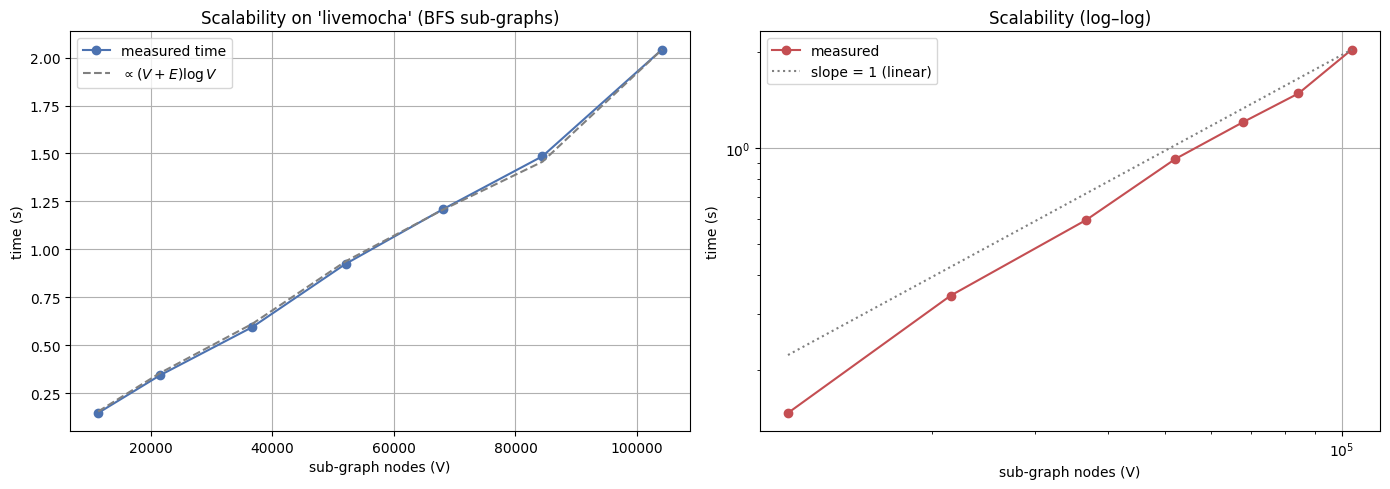

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(sv, st, "o-", color="#4C72B0", label="measured time")
k = st[-1] / sw[-1]
ax.plot(sv, sw * k, "--", color="gray", label=r"$\propto (V+E)\log V$")
ax.set_title(f"Scalability on '{scale_name}' (BFS sub-graphs)")
ax.set_xlabel("sub-graph nodes (V)"); ax.set_ylabel("time (s)"); ax.legend()

ax = axes[1]
ax.loglog(sv, st, "o-", color="#C44E52", label="measured")
# reference slope-1 (linear-ish) line through last point
ref = st[-1] * (sv / sv[-1])
ax.loglog(sv, ref, ":", color="gray", label="slope = 1 (linear)")
ax.set_title("Scalability (log–log)")
ax.set_xlabel("sub-graph nodes (V)"); ax.set_ylabel("time (s)"); ax.legend()

plt.tight_layout()
plt.show()

### 5b. Growth curve on the largest dataset

A single, focused **growth curve** for `livemocha` (the largest graph). We fit an
empirical power law $t \approx a \cdot V^{b}$ to the measured points — the exponent
$b$ is the *measured* growth rate. For binary-heap Dijkstra we expect $b$ slightly
above 1 (linearithmic). A smooth fitted curve is drawn through the points and
**extrapolated to 1.5× the full graph** to show the projected cost of a larger graph.

Fitted growth law:  t ≈ 3.041e-06 · V^1.160   (exponent b = 1.160)
  -> b≈1 means linear, b≈1.1 linearithmic, b≈2 quadratic


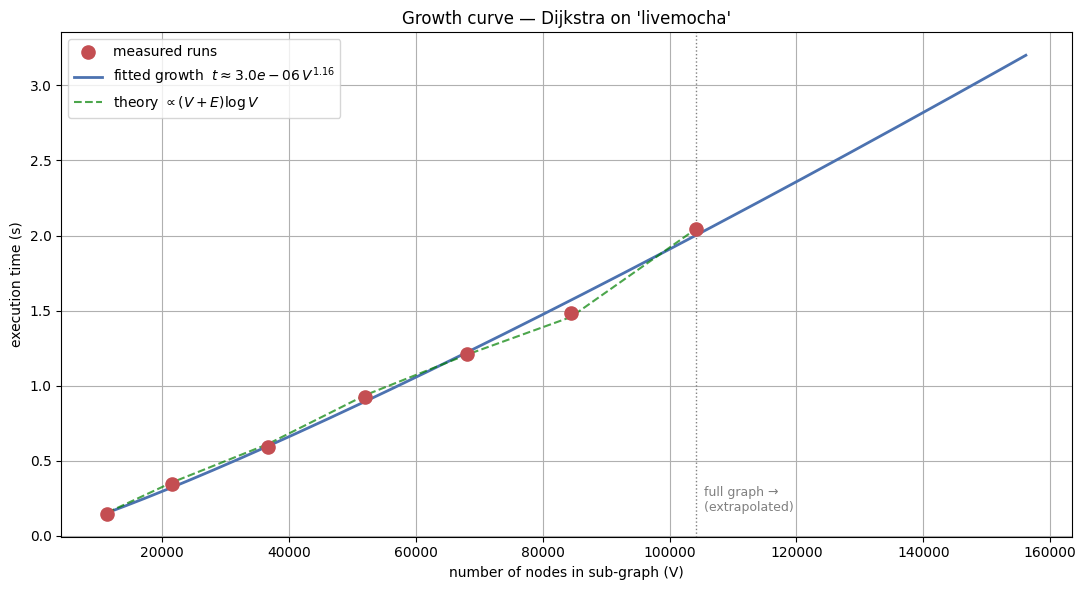

In [9]:
# power-law fit  t = a * V^b   <=>   log t = log a + b*log V
b, log_a = np.polyfit(np.log(sv), np.log(st), 1)
a = np.exp(log_a)
print(f"Fitted growth law:  t ≈ {a:.3e} · V^{b:.3f}   (exponent b = {b:.3f})")
print(f"  -> b≈1 means linear, b≈1.1 linearithmic, b≈2 quadratic")

# smooth curve across the measured range, extrapolated to 1.5x the full graph
v_smooth = np.linspace(sv.min(), sv.max() * 1.5, 200)
t_fit    = a * v_smooth ** b

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(sv, st, s=90, color="#C44E52", zorder=5, label="measured runs")
ax.plot(v_smooth, t_fit, "-", color="#4C72B0", lw=2,
        label=fr"fitted growth  $t \approx {a:.1e}\,V^{{{b:.2f}}}$")
# mark the boundary between measured and extrapolated region
ax.axvline(sv.max(), color="gray", ls=":", lw=1)
ax.text(sv.max(), ax.get_ylim()[1]*0.05, "  full graph →\n  (extrapolated)",
        fontsize=9, color="gray")
# theoretical (V+E)logV reference, scaled to the data
k = st[-1] / sw[-1]
ax.plot(sv, sw * k, "--", color="green", alpha=0.7, label=r"theory $\propto (V+E)\log V$")
ax.set_title(f"Growth curve — Dijkstra on '{scale_name}'")
ax.set_xlabel("number of nodes in sub-graph (V)")
ax.set_ylabel("execution time (s)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Running-time distribution over random sources

A single source can be lucky/unlucky. Here we run Dijkstra from **many random
source nodes** in each dataset and look at the distribution of running times —
this characterises the typical per-query cost.

bitcoin-alpha  median=   10.38 ms  mean=   10.24 ms  max=   11.40 ms


bitcoin-otc    median=   17.40 ms  mean=   17.51 ms  max=   21.49 ms


advogato       median=   20.76 ms  mean=   14.74 ms  max=   24.98 ms


epinions       median=   58.05 ms  mean=   57.85 ms  max=   64.26 ms


livemocha      median= 1243.13 ms  mean= 1246.42 ms  max= 1278.98 ms


/var/folders/s0/hkchwmhn6rv0_7h0_fvq5tx80000gn/T/ipykernel_62639/1919674232.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)


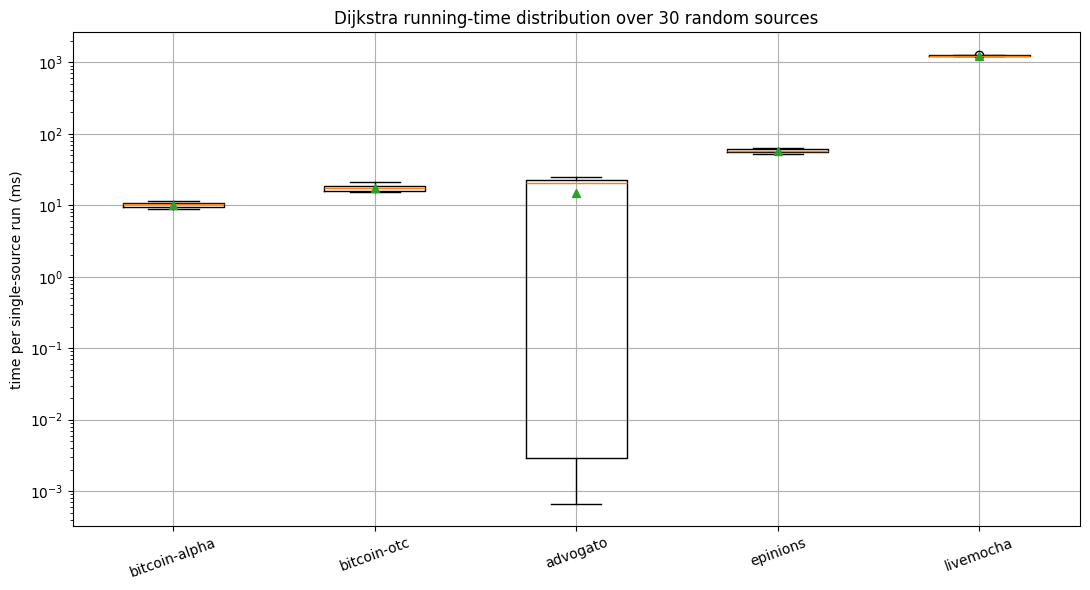

In [10]:
N_SOURCES = 30
dist_times = {}
for name in [r["name"] for r in results]:
    g = graphs[name]
    nodes = list(g.keys())
    picks = random.sample(nodes, min(N_SOURCES, len(nodes)))
    ts = []
    for s in picks:
        t0 = time.perf_counter()
        dijkstra(g, s)
        ts.append(time.perf_counter() - t0)
    dist_times[name] = ts
    print(f"{name:14s} median={np.median(ts)*1000:8.2f} ms  "
          f"mean={np.mean(ts)*1000:8.2f} ms  max={np.max(ts)*1000:8.2f} ms")

fig, ax = plt.subplots(figsize=(11, 6))
labels = list(dist_times.keys())
data = [np.array(dist_times[n]) * 1000 for n in labels]   # ms
ax.boxplot(data, labels=labels, showmeans=True)
ax.set_title(f"Dijkstra running-time distribution over {N_SOURCES} random sources")
ax.set_ylabel("time per single-source run (ms)")
ax.tick_params(axis='x', rotation=20)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 7. Summary table

Everything collected in one place, ordered by number of nodes.

In [11]:
hdr = f"{'dataset':14s}{'V':>9}{'E':>11}{'time(s)':>10}{'mem(MB)':>10}{'med ms/run':>12}"
print(hdr); print("-" * len(hdr))
for r in results:
    med = np.median(dist_times[r['name']]) * 1000
    print(f"{r['name']:14s}{r['V']:>9,}{r['E']:>11,}"
          f"{r['time_s']:>10.4f}{r['mem_mb']:>10.1f}{med:>12.2f}")

dataset               V          E   time(s)   mem(MB)  med ms/run
------------------------------------------------------------------
bitcoin-alpha     3,783     24,186    0.0207       0.5       10.38
bitcoin-otc       5,881     35,592    0.0378       1.2       17.40
advogato          6,551     51,332    0.0459       1.0       20.76
epinions         26,588    100,120    0.1163       4.9       58.05
livemocha       104,103  2,193,083    2.1846      16.0     1243.13


### Takeaways

- **Time and memory both grow with graph size**, dominated by `V + E`. Sorting the
  datasets by node count, the largest graph (`livemocha`) is the most expensive on
  every metric, as the `O((V+E) log V)` bound predicts.
- The **scalability panels** show the per-graph time curve tracking the
  `(V+E)·log V` reference closely — i.e. near-linearithmic growth, not quadratic.
- **Memory** scales linearly with `V + E` (the adjacency list plus the heap and
  distance map), matching the `O(V + E)` space bound.
- The **running-time distribution** shows variance across source nodes is small
  relative to the differences *between* datasets, so graph size — not the choice
  of source — is the dominant factor.
